In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

In [4]:
# creating dummy data
np.random.seed(42)

# Generate 1000 CGPAs (Normally distributed around 7.0, ranging roughly 4.0 to 10.0)
cgpa = np.random.normal(7.0, 1.5, 1000)
cgpa = np.clip(cgpa, 4.0, 10.0) # Keep realistic bounds

# Generate Placement LPA (Dependent on CGPA + some random noise/luck)
# Formula: LPA = (CGPA * 1.5) - 3 + random_noise
noise = np.random.normal(0, 1.5, 1000)
lpa = (cgpa * 1.5) - 3 + noise
lpa = np.clip(lpa, 2.0, 40.0) # Keep realistic bounds

df = pd.DataFrame({'CGPA': cgpa, 'LPA': lpa})

In [5]:
# Split the data
X = df[['CGPA']].values
y = df['LPA'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data Generated!! Trainig on {X_train.shape[0]} rows")

Data Generated!! Trainig on 800 rows


# Phase1:
 I am applying SciKit Learn Linear Regression model and predict the *results*

In [15]:
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train, y_train)

m_sklearn = lr_sklearn.coef_[0]
b_sklearn = lr_sklearn.intercept_

print(f"Sklearn Slope (m): {m_sklearn:.4f}")
print(f"Sklearn Intercept (b): {b_sklearn:.4f}")

y_pred_sklearn = lr_sklearn.predict(X_test)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)

print(f"Mean Squared Error: {mse_sklearn:.4f}")

Sklearn Slope (m): 1.4278
Sklearn Intercept (b): -2.3565
Mean Squared Error: 2.2108


# Phase2:
my custom LinearRegression class

In [16]:
class NewLR:
  def __init__(self):
    self.m = 0
    self.b = 0

  def fit(self, X_train, y_train):
    # we need 1-D array to perform raw math calculation
    X_train = X_train.ravel()

    x_mean = X_train.mean()
    y_mean = y_train.mean()

    # Calculate Slope (m) = Covariance(X,y) / Variance(X)
    numerator = 0
    denominator = 0

    for i in range(X_train.shape[0]):
      numerator += (X_train[i] - x_mean) * (y_train[i] - y_mean)
      denominator += (X_train[i] - x_mean) * (X_train[i] - x_mean)

    self.m = numerator / denominator

    # Calculate Intercept (b) = y_mean - m * x_mean
    self.b = y_mean - (self.m * x_mean)

  def predict(self,X_test):
    # y = mx + b
    return (self.m * X_test.ravel() + self.b)

In [18]:
lr_custom = NewLR()
lr_custom.fit(X_train, y_train)

print(f"Custom Slope (m): {lr_custom.m:.4f}")
print(f"Custom Intercept (b): {lr_custom.b:.4f}")

y_pred_custom = lr_custom.predict(X_test)
mse_custom = mean_squared_error(y_test, y_pred_custom)

print(f"Mean Squared Error: {mse_custom:.4f}")

Custom Slope (m): 1.4278
Custom Intercept (b): -2.3565
Mean Squared Error: 2.2108


# Final performance Comparison

In [19]:
print("\n--- Final Performance Comparison ---")
print(f"Scikit-Learn MSE: {mse_sklearn:.6f}")
print(f"Custom NewLR MSE: {mse_custom:.6f}")
print("Did they match exactly? ->", np.allclose(y_pred_sklearn, y_pred_custom))


--- Final Performance Comparison ---
Scikit-Learn MSE: 2.210838
Custom NewLR MSE: 2.210838
Did they match exactly? -> True


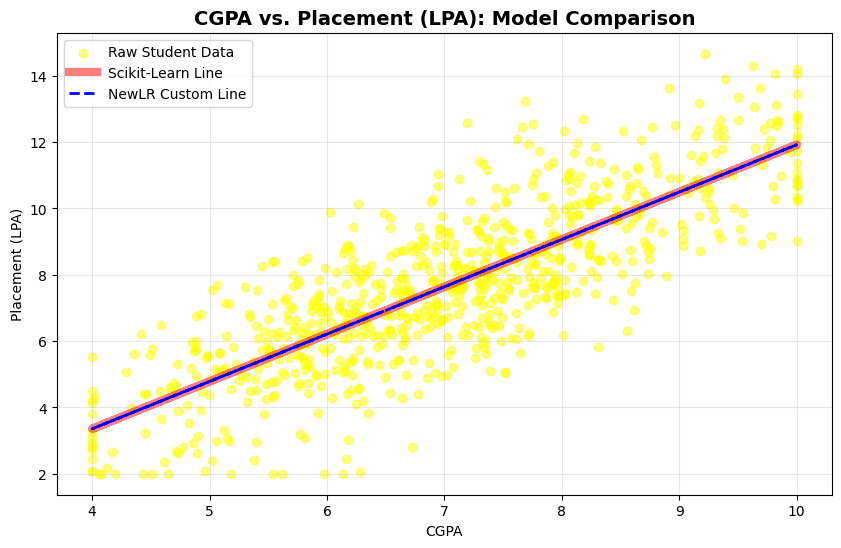


Look closely at the graph: The dashed blue line perfectly overlays the thick red line. Our math is flawless!


In [21]:
# 5. VISUALIZE THE PROOF
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the raw data points
plt.scatter(X_train, y_train, color='yellow', alpha=0.5, label='Raw Student Data')

# Plot the Scikit-Learn Line (Thick Red)
plt.plot(X_train, lr_sklearn.predict(X_train), color='red', linewidth=6, alpha=0.5, label='Scikit-Learn Line')

# Plot your Custom Line (Thin Blue Dash)
plt.plot(X_train, lr_custom.predict(X_train), color='blue', linewidth=2, linestyle='--', label='NewLR Custom Line')

plt.title('CGPA vs. Placement (LPA): Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('CGPA')
plt.ylabel('Placement (LPA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nLook closely at the graph: The dashed blue line perfectly overlays the thick red line. Our math is flawless!")